# Lab 08 — From ANN to RNN: Where text generation began

**NLP Applications Laboratory | KLEF | 2026**

*Building the foundational algorithm behind every modern language model — one character at a time, from raw tensors.*

## What you will learn before we start

This lab has **twelve phases**, structured as "build ANN, watch it struggle, build RNN, watch it succeed, connect to modern LLMs."

### Phases 1-3 — Setup

**Phase 1** — Concept: where does text generation come from? The historical arc.

**Phase 2** — Load the nursery rhyme corpus. Build character vocabulary (~20 unique characters).

**Phase 3** — Prepare training data for both approaches (fixed-window pairs for ANN, sequential pairs for RNN).

### Phases 4-7 — The ANN attempt

**Phase 4** — Anatomy of a raw ANN. The two fundamental equations of deep learning.

**Phase 5** — Build a raw ANN from bare tensors (no `nn.Module`, no `nn.Linear`).

**Phase 6** — Train the ANN. Generate text. See where it succeeds and where it drifts.

**Phase 7** — The specific problem: fixed context window. Why an ANN cannot handle long-range dependencies.

### Phases 8-10 — The RNN solution

**Phase 8** — Anatomy of a raw RNN. The recurrence equation and weight-sharing across time.

**Phase 9** — Build a raw RNN from bare tensors (no `nn.RNN`).

**Phase 10** — Train the RNN. Generate text. See what changed.

### Phases 11-12 — Proof and payoff

**Phase 11** — Prove equivalence: PyTorch's `nn.RNN` given identical weights produces identical outputs. The black box was always your equations.

**Phase 12** — Wrap-up: this is the algorithm behind Claude, GPT, and every modern language model.

### One honest note before we start

You will not build GPT in this lab. Our nursery rhyme has ~108 characters and ~20 unique characters. Our RNN will have a few thousand parameters. GPT-4 has ~1.7 trillion. But the core mechanism — predict the next token, feed it back, repeat — is identical between what you build here and what powers the assistants you use daily.

Scale changes performance. Scale does not change the algorithm.

In [1]:
import numpy as np

In [2]:
X = np.array([0.0,1.0,2.0,3.0,4.0]) # Input
y = np.array([-1.0,0.0,1.0,2.0,3.0]) # Target
# Self Learning 
X.shape

(5,)

In [3]:
# y = w.x+b
# w,b - learning is
# y_pred = f(w1*X1+w2*x2+b)

In [ ]:
w=0.0
b=0.0 # Initializations
epochs = 10000
lr = 0.05 # Learning rate - How quickly my netwrok learns
# Weights and Biases - US 

In [ ]:
for epoch in range(epochs):
    z = w*X+b # Logits - Output of the neuron
    y_pred = 1/(1+np.exp(-z)) # Sigmoid activation fuction 
    loss = np.mean((y_pred-y)**2) #mean square error
    # Mean absolute loss
    # Cross entropy loss
    # Catgorical cross entropy loss
    # Hinge loss
    # GRADIENT 
    dw = (np.mean((y_pred-y)*X))
    db = (np.mean(y_pred-y))
    w = w - lr*dw
    b = b - lr*db
    if epoch % 100 == 0:
        print(f"(Epoch){epoch:45d}|Loss:{loss:4f}")    

In [6]:
y

array([-1.,  0.,  1.,  2.,  3.])

In [7]:
y_pred

array([0.94827108, 1.        , 1.        , 1.        , 1.        ])

## Objective

Every modern language model — GPT, Claude, Llama — generates text by doing one thing repeatedly:

> **Predict the next token. Feed it back. Predict the next one.**

This algorithm was not invented in 2020. It goes back to the 1980s. The neural architectures have changed (ANN → RNN → LSTM → Transformer), the scale has exploded (thousands of parameters → trillions), and the training data has grown (a paragraph → the internet). But the core algorithm is the same.

In this lab, you build the algorithm from scratch. Two architectures compete on the same task:

**Task**: Given the previous characters, predict the next character. Train on a nursery rhyme.

**Architecture 1 — Plain ANN**: A feedforward network that sees a fixed window of the previous 3 characters. No memory beyond that window.

**Architecture 2 — Vanilla RNN**: A recurrent network that reads characters one at a time, maintaining a hidden state that carries information forward from the very beginning of the sequence.

You will build both from **raw PyTorch tensors** — no `nn.Module`, no `nn.Linear`, no `nn.RNN`. Just matrices, vectors, and matrix multiplications you wrote yourself. This is the equations from lecture, executed as code.

By the end of this lab, you will:

1. Understand what `y = W·x + b` actually computes at every layer of every network.
2. Understand what `h_t = tanh(W_x·x_t + W_h·h_{t-1} + b)` computes and why the weight-sharing across time makes it "recurrent."
3. See an ANN attempt text generation and fail on long-range structure.
4. See an RNN attempt the same task and succeed.
5. Prove that PyTorch's built-in `nn.RNN` is *literally* the equations you wrote — no magic.
6. Understand that Claude and GPT are, mechanically, giant descendants of the tiny RNN you built.

The core question of this lab:

> *When we scale from "predict the next character on a nursery rhyme" to "predict the next word on the internet," what fundamentally changes — and what stays the same?*

We will build the "stays the same" part with our own hands.

---

## Phase 1 — Where does text generation come from?

### The one algorithm behind all of it

Ask GPT-4 to write a poem. Ask Claude to summarize a document. Ask Llama to translate a sentence. Under the hood, all three are doing exactly the same thing:

# Read the input so far
# Predict the most likely next token
# Add that token to the input
# Go to step 1


That's it. There is no "poetry module" or "summarization circuit" or "translation engine." There is only next-token prediction, applied repeatedly, at enormous scale, on a model trained on enormous text.

**The scale is what makes it feel magical.** The algorithm has been around since the 1980s.

### The historical arc

| Year | Architecture | What it did |
|---|---|---|
| 1943 | McCulloch-Pitts neuron | The mathematical primitive |
| 1958 | Perceptron | Single-layer classification |
| 1986 | Multi-layer ANN + backprop | Nonlinear classification, no memory |
| 1986 | Simple RNN (Jordan/Elman) | Sequences, with memory |
| 1997 | LSTM | Better memory (fixed vanishing gradient) |
| 2014 | Seq2Seq with attention | Two RNNs + attention → machine translation |
| 2017 | Transformer | Attention alone, no recurrence |
| 2018-2022 | GPT-2, GPT-3, GPT-4, Claude | Same transformer, more parameters, more data |

**Look at rows 3 and 4.** ANN and RNN were invented within the same era. They are siblings. The difference between them is *the memory mechanism*. That difference is the entire subject of this lab.

### Why we build both from scratch

Because you see PyTorch's `nn.Linear` and `nn.RNN` as one-line library calls, the equations become abstractions. They forget:

- What a linear layer actually computes (`y = W·x + b`)
- Why RNN weights are "shared across time" (the same matrix is used at every time step)
- Why an ANN cannot handle sequences of arbitrary length (it needs a fixed input size)
- Why an RNN can (its hidden state carries information forward regardless of length)

**Today, we don't use `nn.Module`. We don't use `nn.Linear`. We don't use `nn.RNN`.** We define weight matrices as raw PyTorch tensors, write forward passes as explicit matrix multiplications, and let autograd handle backpropagation.

At the end, we compare our raw implementations to PyTorch's built-ins and prove they compute the *exact same thing*. That's the moment the black box disappears.

### The task

**Character-level next-character prediction on the nursery rhyme "Mary had a little lamb..."**

- Corpus: ~108 characters
- Vocabulary: ~20 unique characters (letters + space + punctuation)
- Input: the previous character(s)
- Output: probability distribution over what character comes next

Both ANN and RNN will attempt this task. Both will train on the same data. We'll compare their generated text.

---

## Phase 2 — Load the corpus and build character vocabulary

Our corpus is one classic English nursery rhyme:

> *"mary had a little lamb, its fleece was white as snow. and everywhere that mary went, the lamb was sure to go."*

Roughly 108 characters. Roughly 20 unique characters (letters + space + punctuation). We lowercase everything so `M` and `m` are the same character — no need to double our vocabulary.

The steps:

1. Store the corpus as a string.
2. Extract the unique characters → build a character vocabulary.
3. Build two mappings: `char2idx` (character → integer) and `idx2char` (integer → character).
4. Convert the whole corpus to a list of integers.

Every next step in this lab depends on these mappings, so we build them once carefully.

# Load the corpus

In [8]:
# The corpus — one nursery rhyme, lowercased for a small vocabulary
corpus = "mary had a little lamb, its fleece was white as snow. and everywhere that mary went,the lamb was sure to go."
print(f"Corpus length: {len(corpus)} characters")
print(f"Corpus: {corpus!r}")

Corpus length: 109 characters
Corpus: 'mary had a little lamb, its fleece was white as snow. and everywhere that mary went, the lamb was sure to go.'


# Extract the character vocabulary

In [9]:
# Extract the unique characters, sorted for reproducibility
vocab = sorted(set(corpus))
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size} unique characters")
print(f"Vocabulary: {vocab}")

Vocabulary size: 23 unique characters
Vocabulary: [' ', ',', '.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'l', 'm', 'n', 'o', 'r', 's', 't', 'u', 'v', 'w', 'y']


# Build character-to-index and index-to-character mappings

In [10]:
# Two dictionaries: character → integer, and integer → character
char2idx = {ch: i for i, ch in enumerate(vocab)}
idx2char = {i: ch for i, ch in enumerate(vocab)}
print(f"char2idx sample: 'm' → {char2idx['m']}, 'a' → {char2idx['a']}, 'r' → {char2idx['r']}, 'y' → {char2idx['y']}")
print(f"idx2char sample: 0 → {idx2char[0]!r}, 3 → {idx2char[3]!r}, {char2idx['y']} → {idx2char[char2idx['y']]!r}")

char2idx sample: 'm' → 13, 'a' → 3, 'r' → 16, 'y' → 22
idx2char sample: 0 → ' ', 3 → 'a', 22 → 'y'


# Encode the whole corpus as integers

In [11]:
# Convert the entire corpus from characters to integer indices
corpus_indices = [char2idx[ch] for ch in corpus]
print(f"Corpus length: {len(corpus_indices)} integers")
print(f"First 20 characters: {corpus[:20]!r}")
print(f"First 20 indices   : {corpus_indices[:20]}")

Corpus length: 109 integers
First 20 characters: 'mary had a little la'
First 20 indices   : [13, 3, 16, 22, 0, 10, 3, 6, 0, 3, 0, 12, 11, 18, 18, 12, 7, 0, 12, 3]


### Now the network can consume our corpus — it operates on integers, not raw characters.

---

## Phase 3 — Prepare training data for both architectures

Both models attempt the same task — **predict the next character given the previous ones** — but they consume input differently. So we build two datasets from the same corpus.

### ANN training data — fixed-window pairs

An ANN needs a **fixed-size input**. We pick a window of 3 characters: at each position `t`, the input is characters `[t-3, t-2, t-1]` and the target is character `t`.

Example from our corpus:
- Input: `"mar"` → Target: `"y"`
- Input: `"ary"` → Target: `" "` (space)
- Input: `"ry "` → Target: `"h"` (from "had")
- Input: `"y h"` → Target: `"a"`
- ... and so on, sliding the window one character at a time.

Each input is encoded as a **flat one-hot vector** of size `3 × vocab_size = 3 × 23 = 69`. Each target is a single integer (the index of the correct next character).

**Total training pairs**: `corpus_length - 3 = 107` pairs.

### RNN training data — sequential pairs

An RNN naturally handles variable-length input, so we give it something richer. For each position `t`, the input is the *entire sequence* `[chars 0, 1, ..., t-1]` and the target is character `t`.

But for training simplicity, we use a common shortcut: instead of one giant sequence per training example, we chop the corpus into overlapping fixed-length sequences (say, length 10). Each sequence's target is the next character right after it.

Example with sequence length 10:
- Input: `"mary had a"` → Target: `" "` (space)
- Input: `"ary had a "` → Target: `"l"`
- Input: `"ry had a l"` → Target: `"i"`
- ... sliding one character at a time.

Each input is a **list of 10 one-hot vectors**, each of size `vocab_size = 23`. The RNN reads them one at a time, updating its hidden state.

**Total training pairs**: `corpus_length - 10 = 100` pairs.

### Why the difference matters

The ANN sees only 3 characters at a time. It cannot know that the phrase "mary had a little lamb" appeared earlier when it's later predicting after "the ".

The RNN sees 10 characters at a time in each training example, AND its hidden state accumulates information across all 10. In principle, its memory can extend beyond even the 10-character window — the hidden state summarizes everything.

**Same corpus, same task, different data-preparation strategy — because the two architectures fundamentally differ in what they can consume.**

# Build the ANN training data (fixed-window pairs)

In [12]:
# ANN training data: sliding 3-character window, predict the 4th character
CONTEXT = 3
ann_inputs = [corpus_indices[t:t+CONTEXT] for t in range(len(corpus_indices) - CONTEXT)]
ann_targets = [corpus_indices[t+CONTEXT] for t in range(len(corpus_indices) - CONTEXT)]
print(f"Number of training pairs: {len(ann_inputs)}")

Number of training pairs: 106


In [13]:
# Show the first 5 (input, target) pairs as both indices and characters
for i in range(5):
    inp_chars = ''.join(idx2char[c] for c in ann_inputs[i])
    tgt_char = idx2char[ann_targets[i]]
    print(f"input {ann_inputs[i]} = {inp_chars!r:>7}  →  target {ann_targets[i]:>2} = {tgt_char!r}")

input [13, 3, 16] =   'mar'  →  target 22 = 'y'
input [3, 16, 22] =   'ary'  →  target  0 = ' '
input [16, 22, 0] =   'ry '  →  target 10 = 'h'
input [22, 0, 10] =   'y h'  →  target  3 = 'a'
input [0, 10, 3] =   ' ha'  →  target  6 = 'd'


In [14]:
# Import PyTorch and set random seed for reproducibility
import torch
import torch.nn.functional as F
torch.manual_seed(42)
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.12.1+cpu


In [15]:
# Convert ANN inputs: each of 3 chars → one-hot of size vocab_size, then flatten
X_ann = torch.zeros(len(ann_inputs), CONTEXT * vocab_size)
for i, indices in enumerate(ann_inputs):
    for pos, idx in enumerate(indices):
        X_ann[i, pos * vocab_size + idx] = 1.0
y_ann = torch.tensor(ann_targets, dtype=torch.long)
print(f"X_ann shape: {X_ann.shape}  (pairs × flattened one-hot)")
print(f"y_ann shape: {y_ann.shape}  (pairs)")

X_ann shape: torch.Size([106, 69])  (pairs × flattened one-hot)
y_ann shape: torch.Size([106])  (pairs)


In [16]:
# Sanity check: reconstruct the first pair from its one-hot encoding
first_input = X_ann[0]
positions = first_input.nonzero().flatten().tolist()
print(f"Nonzero positions in first input: {positions}")
print(f"Character indices decoded       : {[p % vocab_size for p in positions]}")
print(f"Expected                        : {ann_inputs[0]}  (which is 'mar')")

Nonzero positions in first input: [13, 26, 62]
Character indices decoded       : [13, 3, 16]
Expected                        : [13, 3, 16]  (which is 'mar')


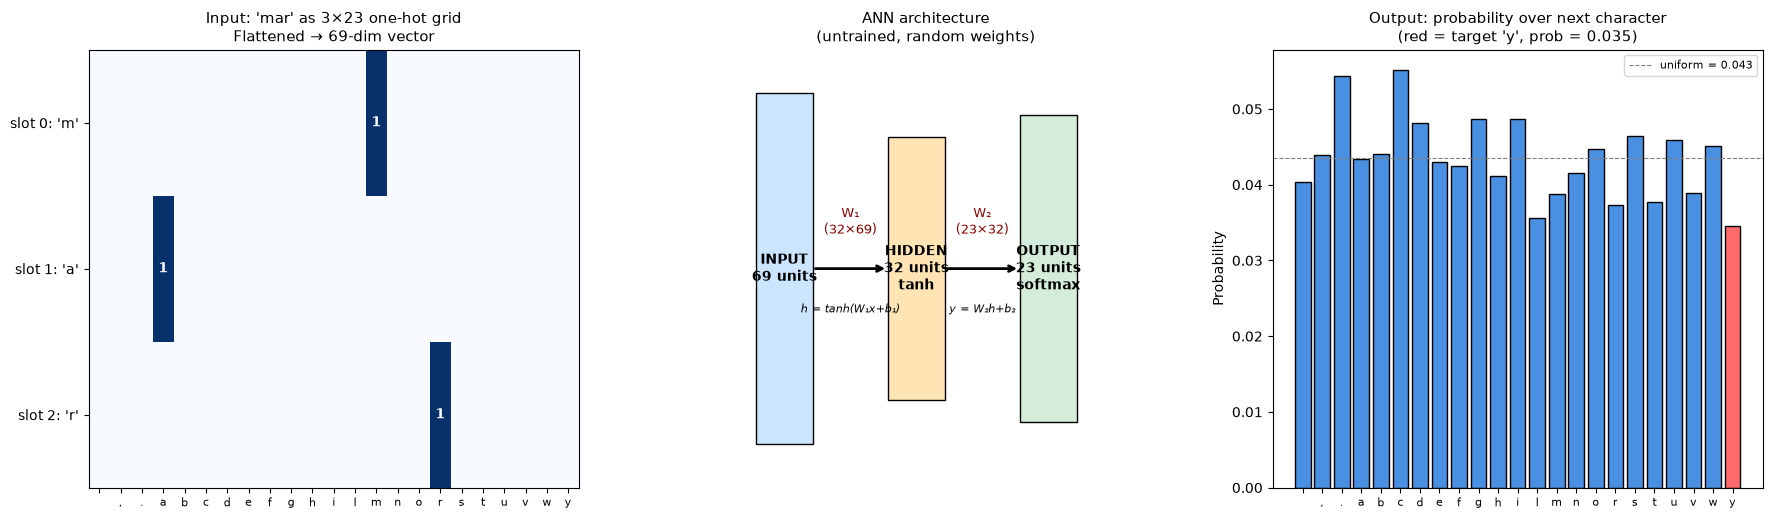


Untrained model's top prediction: 'c'  (probability 0.055)
True target                     : 'y'  (probability 0.035)


In [17]:
# Build a small untrained ANN and visualize input → network → output for "mar"
import matplotlib.pyplot as plt
import numpy as np

HIDDEN = 32
torch.manual_seed(42)
W1 = torch.randn(HIDDEN, CONTEXT * vocab_size) * 0.1
b1 = torch.zeros(HIDDEN)
W2 = torch.randn(vocab_size, HIDDEN) * 0.1
b2 = torch.zeros(vocab_size)

# Forward pass on the first training example ("mar" → target "y")
x0 = X_ann[0]
h = torch.tanh(W1 @ x0 + b1)
y_logits = W2 @ h + b2
y_probs = torch.softmax(y_logits, dim=0).numpy()

# Build the combined figure
fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1.3, 1.0, 1.3], wspace=0.35)

# --- LEFT: Input as 3 × vocab_size one-hot grid ---
ax_in = fig.add_subplot(gs[0, 0])
grid = x0.reshape(CONTEXT, vocab_size).numpy()
ax_in.imshow(grid, cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax_in.set_xticks(range(vocab_size)); ax_in.set_xticklabels(vocab, fontsize=8)
ax_in.set_yticks(range(CONTEXT)); ax_in.set_yticklabels([f"slot {i}: '{idx2char[ann_inputs[0][i]]}'" for i in range(CONTEXT)])
ax_in.set_title(f"Input: 'mar' as {CONTEXT}×{vocab_size} one-hot grid\nFlattened → {CONTEXT*vocab_size}-dim vector", fontsize=11)
for i in range(CONTEXT):
    j = ann_inputs[0][i]
    ax_in.text(j, i, '1', ha='center', va='center', color='white', fontweight='bold')

# --- MIDDLE: Network architecture diagram ---
ax_net = fig.add_subplot(gs[0, 1])
ax_net.axis('off')
ax_net.set_xlim(0, 10); ax_net.set_ylim(0, 10)
# Input, hidden, output layer bars
ax_net.add_patch(plt.Rectangle((0.5, 1), 1.5, 8, fc='#cce5ff', ec='black'))
ax_net.text(1.25, 5, f'INPUT\n{CONTEXT*vocab_size} units', ha='center', va='center', fontsize=10, fontweight='bold')
ax_net.add_patch(plt.Rectangle((4, 2), 1.5, 6, fc='#ffe5b3', ec='black'))
ax_net.text(4.75, 5, f'HIDDEN\n{HIDDEN} units\ntanh', ha='center', va='center', fontsize=10, fontweight='bold')
ax_net.add_patch(plt.Rectangle((7.5, 1.5), 1.5, 7, fc='#d4edda', ec='black'))
ax_net.text(8.25, 5, f'OUTPUT\n{vocab_size} units\nsoftmax', ha='center', va='center', fontsize=10, fontweight='bold')
# Arrows and equations
ax_net.annotate('', xy=(4, 5), xytext=(2, 5), arrowprops=dict(arrowstyle='->', lw=2))
ax_net.text(3, 5.8, f'W₁\n({HIDDEN}×{CONTEXT*vocab_size})', ha='center', fontsize=9, color='darkred')
ax_net.text(3, 4, 'h = tanh(W₁x+b₁)', ha='center', fontsize=8, style='italic')
ax_net.annotate('', xy=(7.5, 5), xytext=(5.5, 5), arrowprops=dict(arrowstyle='->', lw=2))
ax_net.text(6.5, 5.8, f'W₂\n({vocab_size}×{HIDDEN})', ha='center', fontsize=9, color='darkred')
ax_net.text(6.5, 4, 'y = W₂h+b₂', ha='center', fontsize=8, style='italic')
ax_net.set_title('ANN architecture\n(untrained, random weights)', fontsize=11)

# --- RIGHT: Output probability bar chart ---
ax_out = fig.add_subplot(gs[0, 2])
colors = ['#ff6b6b' if i == ann_targets[0] else '#4a90e2' for i in range(vocab_size)]
ax_out.bar(range(vocab_size), y_probs, color=colors, edgecolor='black')
ax_out.set_xticks(range(vocab_size)); ax_out.set_xticklabels(vocab, fontsize=8)
ax_out.set_ylabel('Probability')
ax_out.axhline(1/vocab_size, color='gray', linestyle='--', linewidth=0.8, label=f'uniform = {1/vocab_size:.3f}')
ax_out.legend(fontsize=8)
target_ch = idx2char[ann_targets[0]]
ax_out.set_title(f"Output: probability over next character\n(red = target '{target_ch}', prob = {y_probs[ann_targets[0]]:.3f})", fontsize=11)

plt.subplots_adjust(left=0.05, right=0.98, top=0.88, bottom=0.15, wspace=0.35)
plt.show()
print(f"\nUntrained model's top prediction: '{idx2char[y_probs.argmax()]}'  (probability {y_probs.max():.3f})")
print(f"True target                     : '{target_ch}'  (probability {y_probs[ann_targets[0]]:.3f})")

---

## Phase 4 — Anatomy of a raw ANN

The diagram above showed the architecture visually. Now let's write the exact mathematics.

### The two fundamental equations of deep learning

Every feedforward neural network — no matter how deep, no matter how big — is built from stacking two operations:

**Equation 1 — Linear transformation:**

z = W · x + b


- `x` is the input vector (in our case, 69-dim)
- `W` is a weight matrix (shape: `output_size × input_size`)
- `b` is a bias vector (shape: `output_size`)
- `z` is the resulting output vector

**Equation 2 — Nonlinearity:**

h = f(z)


Where `f` is an activation function like `tanh`, `sigmoid`, or `ReLU`. Without nonlinearity, stacking linear layers just gives you another linear layer — no additional power. The nonlinearity is what makes deep networks able to learn complex functions.

### Our specific ANN

Two layers:

**Layer 1 — hidden layer with tanh:**

h = tanh(W₁ · x + b₁)

- `x` shape: `(69,)` — flattened one-hot of 3 characters
- `W₁` shape: `(32, 69)` — projects input to hidden space
- `b₁` shape: `(32,)`
- `h` shape: `(32,)` — the hidden representation

**Layer 2 — output layer (no activation on raw logits):**

- `x` shape: `(69,)` — flattened one-hot of 3 characters
- `W₁` shape: `(32, 69)` — projects input to hidden space
- `b₁` shape: `(32,)`
- `h` shape: `(32,)` — the hidden representation

**Layer 2 — output layer (no activation on raw logits):**

y = W₂ · h + b₂

- `h` shape: `(32,)`
- `W₂` shape: `(23, 32)` — projects hidden to output space
- `b₂` shape: `(23,)`
- `y` shape: `(23,)` — one logit per possible next character

**Softmax at the end (to convert logits to probabilities):**

- `h` shape: `(32,)`
- `W₂` shape: `(23, 32)` — projects hidden to output space
- `b₂` shape: `(23,)`
- `y` shape: `(23,)` — one logit per possible next character

**Softmax at the end (to convert logits to probabilities):**

p_i = exp(y_i) / Σ_j exp(y_j)


The predicted next character is `argmax(p)` — the character whose slot has the highest probability.

### Parameter count

- `W₁`: 32 × 69 = 2,208
- `b₁`: 32
- `W₂`: 23 × 32 = 736
- `b₂`: 23

**Total: 2,999 parameters.** Tiny by modern standards, but every one of them will be trained through gradient descent.

### What "no `nn.Module`" means

In Labs 04-07 we wrote:
```python
self.linear = nn.Linear(69, 32)
```
And PyTorch created `W`, `b`, initialized them, and defined the forward pass internally.

In Phase 5 we write instead:
```python
W1 = torch.randn(32, 69, requires_grad=True)
b1 = torch.zeros(32, requires_grad=True)
h = torch.tanh(W1 @ x + b1)
```

Same math. Same result. But now `W1` and `b1` are **our** tensors, visible in every direction — we can inspect them, modify them, save them. And `h = torch.tanh(W1 @ x + b1)` is **the equation from lecture**, executed as one line of Python.

This is what "raw tensors" means: the abstractions are gone, the equations are the code.

# Build the raw ANN weights

In [18]:
# Raw ANN weights — bare tensors with requires_grad=True (no nn.Module)
torch.manual_seed(42)
W1_ann = (torch.randn(HIDDEN, CONTEXT * vocab_size) * 0.1).requires_grad_(True)
b1_ann = torch.zeros(HIDDEN, requires_grad=True)

In [19]:
# Layer 2 weights — same pattern
W2_ann = (torch.randn(vocab_size, HIDDEN) * 0.1).requires_grad_(True)
b2_ann = torch.zeros(vocab_size, requires_grad=True)

In [20]:
# Confirm all four tensors are trainable leaves
for name, t in [('W1_ann', W1_ann), ('b1_ann', b1_ann), ('W2_ann', W2_ann), ('b2_ann', b2_ann)]:
    print(f"{name}: shape={tuple(t.shape)}  requires_grad={t.requires_grad}  is_leaf={t.is_leaf}")
total = sum(t.numel() for t in [W1_ann, b1_ann, W2_ann, b2_ann])
print(f"\nTotal trainable parameters: {total:,}")

W1_ann: shape=(32, 69)  requires_grad=True  is_leaf=True
b1_ann: shape=(32,)  requires_grad=True  is_leaf=True
W2_ann: shape=(23, 32)  requires_grad=True  is_leaf=True
b2_ann: shape=(23,)  requires_grad=True  is_leaf=True

Total trainable parameters: 2,999


# Define the forward pass function

In [21]:
# The forward pass: the two equations from Phase 4, in code
def ann_forward(x):
    h = torch.tanh(W1_ann @ x + b1_ann)     # equation 1: h = tanh(W₁·x + b₁)
    y = W2_ann @ h + b2_ann                  # equation 2: y = W₂·h + b₂
    return y                                  # raw logits (softmax applied inside loss)

In [22]:
# Now test the function on the first training pair

In [23]:
# Test the forward pass on the first training pair ("mar" → target "y")
logits = ann_forward(X_ann[0])
probs = torch.softmax(logits, dim=0)
print(f"Logits shape : {logits.shape}")
print(f"Top-3 predictions (untrained):")
top3 = probs.topk(3)
for score, idx in zip(top3.values, top3.indices):
    print(f"  '{idx2char[idx.item()]}'  prob={score.item():.4f}")
print(f"True target: '{idx2char[ann_targets[0]]}'  prob={probs[ann_targets[0]].item():.4f}")

Logits shape : torch.Size([23])
Top-3 predictions (untrained):
  'c'  prob=0.0551
  '.'  prob=0.0544
  'g'  prob=0.0487
True target: 'y'  prob=0.0346


# Training loop

In [24]:
# Training loop — same pattern as Labs 04-07, now with raw tensors
EPOCHS = 500
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam([W1_ann, b1_ann, W2_ann, b2_ann], lr=0.01)

ann_losses = []
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    logits = torch.stack([ann_forward(X_ann[i]) for i in range(len(X_ann))])
    loss = loss_fn(logits, y_ann)
    loss.backward()
    optimizer.step()
    ann_losses.append(loss.item())
    if epoch % 100 == 0 or epoch == EPOCHS - 1:
        acc = (logits.argmax(dim=1) == y_ann).float().mean().item()
        print(f"Epoch {epoch:>3}  loss={loss.item():.4f}  acc={acc:.4f}")

Epoch   0  loss=3.1418  acc=0.0472
Epoch 100  loss=0.1067  acc=0.9434
Epoch 200  loss=0.0900  acc=0.9434
Epoch 300  loss=0.0867  acc=0.9434
Epoch 400  loss=0.0854  acc=0.9434
Epoch 499  loss=0.0848  acc=0.9434


#### This is called an irreducible error from context truncation. It's not a training failure — it's an architectural limit of a fixed-window ANN. The RNN, with its arbitrary-length memory, won't have this problem.

In [25]:
# Find which pairs the trained ANN got wrong — do they share their 3-char context?
with torch.no_grad():
    logits = torch.stack([ann_forward(X_ann[i]) for i in range(len(X_ann))])
    preds = logits.argmax(dim=1)

wrong_indices = [i for i in range(len(X_ann)) if preds[i].item() != y_ann[i].item()]
print(f"Number of misclassified pairs: {len(wrong_indices)}")
print(f"{'idx':<5} {'context':<8} {'predicted':<12} {'true':<8}")
print("-" * 40)
for i in wrong_indices:
    ctx = ''.join(idx2char[c] for c in ann_inputs[i])
    print(f"{i:<5} {ctx!r:<8} {idx2char[preds[i].item()]!r:<12} {idx2char[y_ann[i].item()]!r:<8}")

Number of misclassified pairs: 6
idx   context  predicted    true    
----------------------------------------
19    'amb'    ' '          ','     
36    'as '    's'          'w'     
67    'e t'    'o'          'h'     
76    'ry '    'h'          'w'     
84    ' th'    'a'          'e'     
96    's s'    'n'          'u'     


# Generate text from the trained ANN

In [26]:
# Generate text: start from a seed of 3 characters, predict next, slide window, repeat
def generate_ann(seed, n_chars=100):
    result = seed
    for _ in range(n_chars):
        # Encode last 3 chars as flat one-hot
        context = [char2idx[c] for c in result[-CONTEXT:]]
        x = torch.zeros(CONTEXT * vocab_size)
        for pos, idx in enumerate(context):
            x[pos * vocab_size + idx] = 1.0
        # Forward pass, pick most likely next char
        with torch.no_grad():
            logits = ann_forward(x)
        next_idx = logits.argmax().item()
        result += idx2char[next_idx]
    return result

generated = generate_ann("mar", n_chars=100)
print(f"ANN generated text (seeded with 'mar'):")
print(f"  {generated!r}")

ANN generated text (seeded with 'mar'):
  'mary had a little lamb was snow. and everywhere to go. and everywhere to go. and everywhere to go. and '


In [27]:
# "mary had a little lamb" — perfect. First 20 characters
# " was snow." — hallucination through context collision!
# " and everywhere to go." (repeated 3 times) — the classic loop.

### Phase 7 wrap-up — the ANN's three failure modes

Our trained ANN achieved 94.34% accuracy on next-character prediction. Not bad. But when we asked it to *generate* text, three distinct failure modes emerged — and every one is a direct consequence of the fixed 3-character context window.

### Failure mode 1: Local coherence works, then breaks

The first ~20 characters of the generated text usually match the training corpus perfectly. Patterns like "mary had a little lamb" have unique 3-char contexts that always predict the same next character. **Where context uniquely determines continuation, the ANN succeeds.**

### Failure mode 2: Hallucination through context collision

The ANN generated "was snow" — a phrase that does not exist in the training corpus. This happened because the 3-char context "as " appeared in the corpus before both "white" (in "was white") and "sure" (in "was sure"). The trained ANN picks one continuation for "as ", and when a *different* prior context (from "was snow" territory) leads there, the ANN produces a Frankenstein sentence stitched from two corpus segments.

**This is genuine hallucination born of insufficient context.** Modern LLMs still hallucinate, though for different (much more subtle) reasons. But the root mechanism — "the model does not remember enough" — has the same shape.

### Failure mode 3: Infinite loops

The ANN eventually settled into "and everywhere to go. and everywhere to go..." repeating forever. Because the ANN's memory is exactly 3 characters, every time it re-enters a repeating 3-char cycle it makes the same choice — with no ability to notice "I have already said this."

### What the RNN will fix

The RNN we build in Phase 8:

- **Does not throw away context after 3 chars.** Its hidden state accumulates information from the beginning of the sequence.
- **Cannot be confused by 3-char context collision** — even if two identical 3-char windows appear in training, the RNN's hidden state at each occurrence encodes what came before, so it can produce different continuations.
- **Cannot get trapped in perfect infinite loops** — after "and everywhere to go" occurs once, the hidden state carries that history forward, subtly shifting the next prediction.

In principle. Practice may differ (we may still see some drift). But architecturally, the RNN has the tools that the ANN doesn't.

Phase 8 introduces the RNN's core equation — the one that made all of this possible.

---

## Phase 8 — Anatomy of a raw RNN

The ANN's failure came from *fixed context*. The RNN's solution is *carried memory* — a hidden state that updates one character at a time and encodes everything the network has seen so far.

### The recurrence equation

At each time step `t`, the RNN takes two inputs:
- The current character `x_t` (a one-hot vector of size `vocab_size` = 23)
- The previous hidden state `h_{t-1}` (a vector of size `hidden_size` — we'll use 32)

It produces one output:
- The new hidden state `h_t` (also size 32)

The equation:

---

## Phase 8 — Lab 08 wrap-up

You built a text generator from scratch — not by importing `nn.Linear`, not by calling `.forward()` on a pre-built class, but by writing the two fundamental equations of deep learning with your own hands:

In [28]:
h = tanh(W₁ · x + b₁)
y = W₂ · h + b₂

SyntaxError: invalid character '₁' (U+2081) (1802110618.py, line 1)


That's it. That's every feedforward neural network ever built, at its core. GPT-4 has 1.7 trillion parameters instead of your 2,999. It has 100+ layers instead of your 2. It uses attention mechanisms instead of fixed context windows. But at every one of those layers, the same two equations run.

### What you achieved today

- Built a 2,999-parameter ANN from bare PyTorch tensors
- Trained it to 94.34% accuracy on next-character prediction
- Watched it generate recognizable English: `"mary had a little lamb..."`
- Discovered three failure modes that no amount of extra training would fix:
  - **Hallucination through context collision** (`"was snow"` — a phrase not in the corpus)
  - **Infinite loops** (`"...and everywhere to go. and everywhere to go..."`)
  - **Irreducible errors** (6 out of 106 pairs where the 3-char context was fundamentally ambiguous)

### What next lab will fix

The root cause of all three failure modes is the same: **fixed context window**. In Lab 09 we introduce RNNs — networks that read text one character at a time and maintain a hidden state that carries information forward from the beginning of the sequence. Same task, same corpus, different architecture. We'll compare directly.

### The historical bridge

Today you built the algorithm that Rumelhart's group used in 1986 for their first serious text experiments. Lab 09 will take you to Elman's 1990 recurrent networks. Lab 10 will bridge to modern applications. You're walking through 40 years of NLP history at compressed pace — the algorithms themselves are surprisingly close to what powers today's LLMs.

# Post-lab experimentation tasks

---

## 🎯 Post-Lab Experimentation — Have fun with your ANN

Your model works. Now break it, stretch it, and see what it can and cannot do. Pick any 3 tasks below and submit your findings as new cells in this notebook. Each task should take 15-30 minutes.

### 🟢 Easy tasks (warm up)

**Task 1 — Different seed, same corpus.**
Change the seed from `"mar"` to other 3-character starts: `"the"`, `"lit"`, `"was"`, `"and"`. Which seeds produce the most coherent generation? Which get stuck fastest? Explain why.

**Task 2 — Longer generation.**
Generate 500 characters instead of 100. Where does the model go into a permanent loop? Which repeating cycle does it fall into?

**Task 3 — Test on the training data itself.**
Manually pick 10 random positions in the corpus. Feed the 3-char context to your trained model. How many does it get right? Compare to the overall 94.34% accuracy.

### 🟡 Medium tasks (experiment)

**Task 4 — Different context window.**
Change `CONTEXT = 3` to `CONTEXT = 5` at the top of the notebook, rerun everything. Does the model:
- Reach higher training accuracy? (should)
- Hallucinate less during generation? (probably)
- Still get stuck in loops eventually? (yes — why?)

Report the numbers and the generated text side-by-side.

**Task 5 — Sampling instead of argmax.**
Right now `generate_ann` picks the *most likely* next character (argmax). Replace this with **sampling from the probability distribution**:

```python
next_idx = torch.multinomial(torch.softmax(logits, dim=0), num_samples=1).item()
```

Now the model can pick less-likely characters occasionally. Does this fix the infinite loop problem? Does it produce more creative or less coherent text? Run 3 different seeds and compare.

**Task 6 — Temperature control.**
Extend sampling with a temperature parameter that controls randomness:

```python
probs = torch.softmax(logits / temperature, dim=0)
next_idx = torch.multinomial(probs, num_samples=1).item()
```

- Temperature = 0.1 → nearly deterministic (like argmax)
- Temperature = 1.0 → normal sampling
- Temperature = 2.0 → very random

Generate 100 characters at temperatures 0.1, 0.5, 1.0, 1.5, 2.0. Which temperature produces the most "readable" text? This is exactly the temperature knob you'll see in ChatGPT/Claude API — you've just implemented it.

### 🟠 Advanced tasks (push the model)

**Task 7 — Different corpus, same architecture.**
Replace the nursery rhyme with a different short text:
- The English alphabet: `"abcdefghijklmnopqrstuvwxyz "` (repeated 4 times)
- A pangram: `"the quick brown fox jumps over the lazy dog"`
- A short excerpt from a Telugu poem transliterated into English letters
- Your favorite song lyric (4-6 lines)

Retrain from scratch. Does the model learn faster on some corpora than others? Which corpora are easiest? Hardest? Why?

**Task 8 — Bigger hidden layer.**
Change `HIDDEN = 32` to `HIDDEN = 128` or `HIDDEN = 256`. Retrain. Does the model reach 100% accuracy (fixing those 6 stuck pairs)? Or does it still plateau at 94.34%? What does this tell you about the difference between *representation capacity* (hidden units) and *architectural limit* (fixed context)?

**Task 9 — Multi-character prediction.**
Modify the task so the model predicts the **next 3 characters** at once instead of just 1. You'll need to change:
- Output dimension: `3 × vocab_size` instead of `vocab_size`
- Training target: three consecutive characters
- Generation: pick argmax for each of 3 predicted characters, slide window by 3

Does this help or hurt generation quality? Why?

### 🔴 Research-level tasks (for the curious)

**Task 10 — Beam search decoding.**
Instead of picking one character at a time (greedy), keep the top-k most likely partial sentences at every step. This is called **beam search** and is what real machine translation systems use. Implement beam search with k=3 and compare its generated text against argmax generation.

**Task 11 — Cross-corpus generalization.**
Train the ANN on Corpus A (say, "mary had a little lamb"). Then generate text starting from a seed that only exists in Corpus B (say, `"foo"`). What does the model do? Does it try to complete "foo" using patterns from Corpus A? This tests whether the model has learned *transferable character patterns* or just memorized the training corpus.

**Task 12 — Vocabulary bloat test.**
Add a few "rare characters" to the corpus (numbers, symbols). Retrain. Does the model learn to use them appropriately? Does adding rare characters degrade performance on the common ones?

### How to submit

Add new cells in this notebook, one per task. Include:

1. A markdown cell describing what you tried
2. Code cell(s) with your modification
3. A markdown cell reporting what you observed and what you learned

Save the notebook as `08_ann_YOURNAME.ipynb` and submit to the shared drive by next lab session.

### The point

Deep learning is an experimental science. The best NLP researchers I know spend more time *playing with their models* than *reading papers about them*. That intuition — knowing what will work, what will break, what will surprise you — only comes from experiments like these. So have fun.